# JEM application: Coupled Spring System


In this tutorial, we are going to build a two springs that interacts with each other. 

## Single Spring

Imagine first there is a metal ball with mass $m$ attached to a spring such that it feels the restoring force $- k \left(x - X\right)$, where $k$ is the restoring coefficient, $x$ the position of the metal ball, and $X$ the restoring center. The governing equation is
$$
m \frac{\mathrm{d}^2 x}{\mathrm{d}t^2} = - k \left(x - X\right)
$$
or let $\Delta x = x - X$, we can simplify it to
$$
m \frac{\mathrm{d}^2 \Delta x}{\mathrm{d}t^2} = - k \Delta x
$$
We can build such a spring with the following (define $v = \mathrm{d} \Delta x/\mathrm{d}t$):

In [1]:
import jax
import jax.numpy as jnp
from jax.typing import ArrayLike
from dataclasses import dataclass
import tree_math

from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

@tree_math.struct
@dataclass
class SpringCarry:
    t: ArrayLike  # time
    x: ArrayLike  # position
    v: ArrayLike  # velocity
    m: ArrayLike  # mass
    k: ArrayLike  # spring coefficient
    f: ArrayLike  # external force

class Spring:

    def __init__(self, init_x, init_v, k, m, dt):
        self.init_x = init_x
        self.init_v = init_v
        self.k = k
        self.m = m
        self.dt = dt

    def initialize(self):
        return SpringCarry(
            t = jnp.array(0),
            x = jnp.array(self.init_x),
            v = jnp.array(self.init_v),
            m = jnp.array(self.m),
            k = jnp.array(self.k),
            f = jnp.array(0),
        )

    def generate_step_function(self):
        dt = self.dt
        def step_function(carry, step):
            """Integrates one time step of a harmonic oscillator."""

            # Physics: a = -k/m * x + f
            acceleration = - (carry.k * carry.x + carry.f) / carry.m

            # Update state (Semi-implicit Euler for better stability)
            new_v = carry.v + acceleration * dt
            new_x = carry.x + new_v * dt

            carry.v = new_v
            carry.x = new_x
            carry.t += dt

            return carry, dict(t=carry.t, x=carry.x, v=carry.v, f=carry.f)
            
        return step_function

/home/tienyiao/miniconda3/envs/jaxesm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The execution using `jax.lax.scan` is

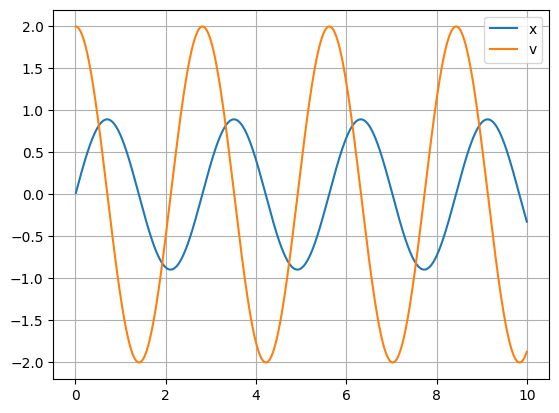

In [2]:
total_time = 10
spring = Spring(init_x=0, init_v=2, k=5.0, m=1.0, dt=0.01)
final_carry, predictions = jax.lax.scan(
    spring.generate_step_function(),
    spring.initialize(),
    jnp.arange(int(total_time / spring.dt)),
)

import matplotlib.pyplot as plt
x = predictions["x"]
v = predictions["v"]
t = predictions["t"]

fig, ax = plt.subplots(1,1)
ax.plot(t, x, label="x")
ax.plot(t, v, label="v")
ax.legend()
ax.grid()
plt.show()

## Two Coupled Springs

Now we want to simulate two springs that interacts with each other.

\begin{align}
m_1 \frac{\mathrm{d}^2 \Delta x_1}{\mathrm{d}t^2} &= - k_1 \Delta x_1 + k^* \left( \Delta x_2 - \Delta x_1 \right) \\
m_2 \frac{\mathrm{d}^2 \Delta x_2}{\mathrm{d}t^2} &= - k_2 \Delta x_2 - k^* \left( \Delta x_2 - \Delta x_1 \right)
\end{align}

where 1 and 2 denote springs 1 and 2, $\Delta x_1 = x_1 - X_1$ and $\Delta x_2 = x_2 - X_2$.

Here we define the interaction function:

In [3]:
k_star = 1.0
def interaction(coupled_carry):
    f_star = (coupled_carry["spring2"].x - coupled_carry["spring1"].x) * k_star
    coupled_carry["spring1"].f = f_star
    coupled_carry["spring2"].f = - f_star
    return coupled_carry

### Using JEM to Couple Springs

In [4]:
total_time = 50
dt = 0.01
model = Coupler(
    components=dict(
        spring1=Spring(init_x=0, init_v=4, k=5.0, m=5.0, dt=dt),
        spring2=Spring(init_x=4, init_v=0, k=5.0, m=3.0, dt=dt),
    ),
    mappers=dict(interaction=interaction),
)

initial_coupled_carry, final_coupled_carry, predictions = model.run(
    workflow=["interaction", "spring1", "spring2"],
    iterations = int(total_time / dt),
)

Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Exception happens when resolving `predictions_to_xarray`: The method `predictions_to_xarray` is not found.
Member name `predictions_to_xarray` is optional. Now set to None..
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Exception happens when resolving `get_info`: The method `get_info` is not found.
Member name `get_info` is optional. Now set to None..
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Exception happens when resolving `predictions_to_xarray`: The met

Simulation: 100%|███████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 63159.81it/s]


### Results

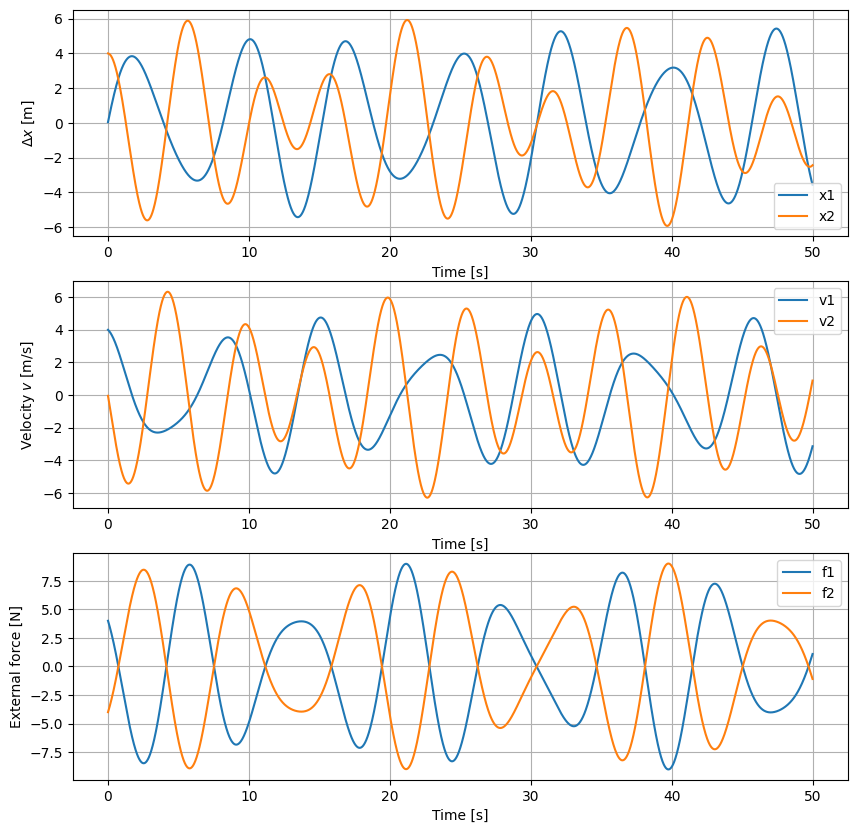

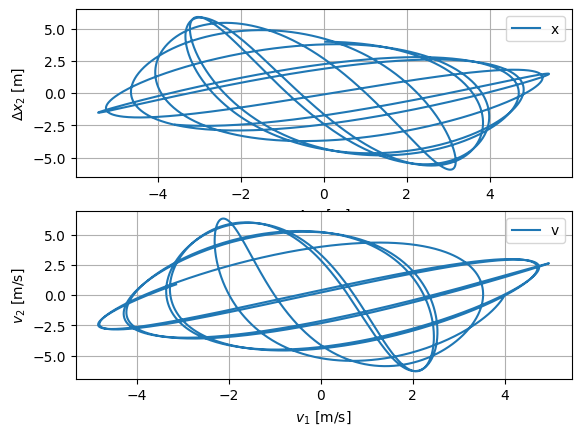

In [16]:
import matplotlib.pyplot as plt

x1 = predictions["spring1"]["x"]
v1 = predictions["spring1"]["v"]
x2 = predictions["spring2"]["x"]
v2 = predictions["spring2"]["v"]
f1 = predictions["spring1"]["f"]
f2 = predictions["spring2"]["f"]
t = predictions["spring1"]["t"]

# Figure 1: x-t 
fig, ax = plt.subplots(3,1, figsize=(10,10))
ax[0].plot(t, x1, label="x1")
ax[0].plot(t, x2, label="x2")
ax[1].plot(t, v1, label="v1")
ax[1].plot(t, v2, label="v2")
ax[2].plot(t, f1, label="f1")
ax[2].plot(t, f2, label="f2")

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].grid()
ax[1].grid()
ax[2].grid()

for _ax in ax:
    _ax.set_xlabel("Time [s]")
    
ax[0].set_ylabel("$\\Delta x$ [m]")
ax[1].set_ylabel("Velocity $ v$ [m/s]")
ax[2].set_ylabel("External force [N]")

# Figure 2: x-v
fig, ax = plt.subplots(2,1)
ax[0].plot(x1, x2, label="x")
ax[1].plot(v1, v2, label="v")

ax[0].legend()
ax[1].legend()

ax[0].grid()
ax[1].grid()

ax[0].set_xlabel("$\\Delta x_1$ [m]")
ax[0].set_ylabel("$\\Delta x_2$ [m]")

ax[1].set_xlabel("$v_1$ [m/s]")
ax[1].set_ylabel("$v_2$ [m/s]")


plt.show()